## FABlib API References Examples

- [fablib.show_config](https://fabric-fablib.readthedocs.io/en/latest/fablib.html#fabrictestbed_extensions.fablib.fablib.FablibManager.show_config)
- [fablib.list_sites](https://fabric-fablib.readthedocs.io/en/latest/fablib.html#fabrictestbed_extensions.fablib.fablib.FablibManager.list_sites)
- [fablib.list_hosts](https://fabric-fablib.readthedocs.io/en/latest/fablib.html#fabrictestbed_extensions.fablib.fablib.FablibManager.list_hosts)
- [fablib.new_slice](https://fabric-fablib.readthedocs.io/en/latest/fablib.html#fabrictestbed_extensions.fablib.fablib.FablibManager.new_slice)
- [slice.add_node](https://fabric-fablib.readthedocs.io/en/latest/slice.html#fabrictestbed_extensions.fablib.slice.Slice.add_node)
- [slice.submit](https://fabric-fablib.readthedocs.io/en/latest/slice.html#fabrictestbed_extensions.fablib.slice.Slice.submit)
- [slice.get_nodes](https://fabric-fablib.readthedocs.io/en/latest/slice.html#fabrictestbed_extensions.fablib.slice.Slice.get_nodes)
- [slice.list_nodes](https://fabric-fablib.readthedocs.io/en/latest/slice.html#fabrictestbed_extensions.fablib.slice.Slice.list_nodesß)
- [slice.show](https://fabric-fablib.readthedocs.io/en/latest/slice.html#fabrictestbed_extensions.fablib.slice.Slice.show)
- [node.execute](https://fabric-fablib.readthedocs.io/en/latest/node.html#fabrictestbed_extensions.fablib.node.Node.execute)
- [slice.delete](https://fabric-fablib.readthedocs.io/en/latest/slice.html#fabrictestbed_extensions.fablib.slice.Slice.delete) 

In [1]:
import datetime
import json
import asyncio
from configuration import SLICE_NAME
from utils import upload_and_execute_file, override_configuration_files, upload_file, execute_file
import pandas as pd

from fabrictestbed_extensions.fablib.fablib import FablibManager as fablib_manager

fablib = fablib_manager()

fablib.show_config();

Orchestrator,orchestrator.fabric-testbed.net
Credential Manager,cm.fabric-testbed.net
Core API,uis.fabric-testbed.net
Artifact Manager,artifacts.fabric-testbed.net
Token File,/home/fabric/.tokens.json
Project ID,49f65ad7-d8a2-4ab9-8ca0-ba777a2e0ea2
Bastion Host,bastion.fabric-testbed.net
Bastion Username,apipilikas_0000444352
Bastion Private Key File,/home/fabric/work/fabric_config/fabric_bastion_key
Slice Public Key File,/home/fabric/work/fabric_config/slice_key.pub
Slice Private Key File,/home/fabric/work/fabric_config/slice_key


In [2]:
%%time
image = "default_ubuntu_24"

# Please adhere to the following regex for naming: /[a-z][a-z0-9]+/
# note: see above, renamed the agent names to only have hyphens, not underscores 

node_configurations = [
    {
        "type": "control",
        "cores": 2,
        "ram": 8,
        "disk": 100,
        "site": "AMST",
        "host": "amst-w3.fabric-testbed.net",
    },
    {
        "type": "dynamos",
        "cores": 4,
        "ram": 16,
        "disk": 100,
        "site": "AMST",
        "host": "amst-w3.fabric-testbed.net",
    },
    {
        "type": "agent",
        "name": "server",
        "cores": 4,
        "ram": 16,
        "disk": 100,
        "site": "AMST",
        "host": "amst-w3.fabric-testbed.net",
    },
    {
        "type": "agent",
        "name": "clientone",
        "cores": 4,
        "ram": 16,
        "disk": 100,
        "site": "LOSA",
        "host": "losa-w3.fabric-testbed.net",
    },
    {
        "type": "agent",
        "name": "clienttwo",
        "cores": 8,
        "ram": 16,
        "disk": 100,
        "site": "TOKY",
        "host": "toky-w3.fabric-testbed.net",
    },
    {
        "type": "agent",
        "name": "clientthree",
        "cores": 8,
        "ram": 16,
        "disk": 100,
        "site": "AMST",
        "host": "amst-w3.fabric-testbed.net",
    },
    {
        "type": "thirdparty",
        "name": "surf",
        "cores": 8,
        "ram": 16,
        "disk": 100,
        "site": "TOKY",
        "host": "toky-w3.fabric-testbed.net",
    }
]

sites = list(set([configuration["site"] for configuration in node_configurations]))
agents = [configuration["name"] for configuration in node_configurations if configuration["type"] == "agent"]
thirdparties = [configuration["name"] for configuration in node_configurations if configuration["type"] == "thirdparty"]

def create_node(slice, configuration):
    if (configuration["type"] == "control"): 
        configuration["name"] = "control"

    if (configuration["type"] == "dynamos"): 
        configuration["name"] = "dynamos"
    
    return slice.add_node(name=configuration["name"], 
                          site=configuration["site"], 
                          host=configuration["host"], 
                          cores=configuration["cores"], 
                          ram=configuration["ram"], 
                          disk=configuration["disk"], 
                          validate=True, 
                          raise_exception=True, 
                          image=image)
    

CPU times: user 19 μs, sys: 2 μs, total: 21 μs
Wall time: 28.4 μs


In [3]:
%%time
slice = fablib.get_slice(name=SLICE_NAME);
nodes = slice.get_nodes();

nodes_and_network_per_site = [
    (site, [node for node in nodes if node.get_site() == site], slice.get_network(name=f"Network-{site}"))
    for site in sites
]
networks = [network for (_, _, network) in nodes_and_network_per_site]

nodes_network_ips_per_site = [
    (site, nodes, network, network.get_available_ips(len(nodes)))
    for (site, nodes, network) in nodes_and_network_per_site
]

User: apipilikas@gmail.com bastion key is valid!
Configuration is valid
CPU times: user 374 ms, sys: 17 ms, total: 391 ms
Wall time: 4.38 s


AttributeError: 'NoneType' object has no attribute 'get_available_ips'

In [5]:
%%time
def assign_ip(site, network, available_ips, node):
    interface = node.get_interface(network_name=f"Network-{site}")
    address = available_ips.pop(0)
    network_gateway = network.get_gateway()
    network_subnet = network.get_subnet()

    network.allocate_ip(address)
    interface.ip_addr_add(addr=address, subnet=network_subnet)
    node.ip_route_add(subnet=network_subnet, gateway=network_gateway)

    # For the multisite IPv4 connection
    for network in networks:
        node.ip_route_add(subnet=network.get_subnet(), gateway=network_gateway)

    return address

ips = [assign_ip(site, network, ips, node) for (site, nodes, network, ips) in nodes_network_ips_per_site for node in nodes];

CPU times: user 14 μs, sys: 2 μs, total: 16 μs
Wall time: 19.1 μs


NameError: name 'nodes_network_ips_per_site' is not defined

In [6]:
%%time
slice = fablib.get_slice(name=SLICE_NAME);
nodes = slice.get_nodes();

for node in nodes:
    print(node.get_name())
    ssh_command = node.get_ssh_command().replace(
        "-i /home/fabric/work/fabric_config/slice_key", "-i ~/.ssh/keys/FABRIC-slice_key"
    ).replace(
        "-F /home/fabric/work/fabric_config/ssh_config ", ""
    )
    
    print(ssh_command);

control
ssh -i ~/.ssh/keys/FABRIC-slice_key ubuntu@2001:610:2d0:fabc:f816:3eff:fe67:fd10
dynamos
ssh -i ~/.ssh/keys/FABRIC-slice_key ubuntu@2001:610:2d0:fabc:f816:3eff:fe98:1cce
server
ssh -i ~/.ssh/keys/FABRIC-slice_key ubuntu@2001:610:2d0:fabc:f816:3eff:fe50:837d
aggregator
ssh -i ~/.ssh/keys/FABRIC-slice_key ubuntu@2001:610:2d0:fabc:f816:3eff:fef7:ced3
authority
ssh -i ~/.ssh/keys/FABRIC-slice_key ubuntu@2001:610:2d0:fabc:f816:3eff:fe4a:4d9a
clientone
ssh -i ~/.ssh/keys/FABRIC-slice_key ubuntu@2001:610:2d0:fabc:f816:3eff:fe54:989
clienttwo
ssh -i ~/.ssh/keys/FABRIC-slice_key ubuntu@2001:610:2d0:fabc:f816:3eff:fe7c:4f5a
clientthree
ssh -i ~/.ssh/keys/FABRIC-slice_key ubuntu@2001:610:2d0:fabc:f816:3eff:fe1c:e52c
surf
ssh -i ~/.ssh/keys/FABRIC-slice_key ubuntu@2001:610:2d0:fabc:f816:3eff:fe9e:98e1
CPU times: user 171 ms, sys: 7.26 ms, total: 179 ms
Wall time: 533 ms


In [8]:
%%time
def get_ip(node):
    interface = node.get_interface(network_name=f"Network-{node.get_site()}")
    return interface.get_ip_addr()

nodes_dict= dict()

for node in nodes[:]:
    ip = get_ip(node)
    name = node.get_name()
    nodes_dict[name] = {"ip": ip, "node": node}
    print(f"{name}: {ip}")

print(nodes_dict)


control: 10.145.1.2
dynamos: 10.145.1.3
server: 10.145.1.4
aggregator: 10.145.1.5
authority: 10.145.1.6
clientone: 10.145.1.7
clienttwo: 10.145.1.8
clientthree: 10.145.1.9
surf: 10.145.1.10
{'control': {'ip': '10.145.1.2', 'node': <fabrictestbed_extensions.fablib.node.Node object at 0x7d3b55740d70>}, 'dynamos': {'ip': '10.145.1.3', 'node': <fabrictestbed_extensions.fablib.node.Node object at 0x7d3b5572a490>}, 'server': {'ip': '10.145.1.4', 'node': <fabrictestbed_extensions.fablib.node.Node object at 0x7d3b5572a0d0>}, 'aggregator': {'ip': '10.145.1.5', 'node': <fabrictestbed_extensions.fablib.node.Node object at 0x7d3b5572a210>}, 'authority': {'ip': '10.145.1.6', 'node': <fabrictestbed_extensions.fablib.node.Node object at 0x7d3b5572a350>}, 'clientone': {'ip': '10.145.1.7', 'node': <fabrictestbed_extensions.fablib.node.Node object at 0x7d3b55729f90>}, 'clienttwo': {'ip': '10.145.1.8', 'node': <fabrictestbed_extensions.fablib.node.Node object at 0x7d3b5572a5d0>}, 'clientthree': {'ip': '1

In [9]:
main_node=nodes_dict['control']['node']
print(f"The main node for now on is [{main_node.get_name()}]")

The main node for now on is [control]


## Creating virual environment (python / conda)

In [ ]:
# Create a venv to execute the pipeline in python3.10 environment.
main_node.execute("sudo add-apt-repository ppa:deadsnakes/ppa -y")
main_node.execute("sudo apt-get update")
main_node.execute("sudo apt-get install python3.10 python3.10-venv python3.10-dev -y")
main_node.execute("python3.10 -m venv py-venv")
main_node.execute("~/py-venv/bin/python -m pip install --use-pep517 git+https://github.com/SchmollerLab/python-javabridge-windows")
main_node.execute("~/py-venv/bin/pip install 'setuptools<81.0.0'")

In [10]:
# Alternative way as with ppa.launchpadcontent.net we got time out. Probably firewall problem.
# 1. Download and install Miniconda silently
main_node.execute("wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O miniconda.sh")
main_node.execute("bash miniconda.sh -b -p $HOME/miniconda")

# 2. Accept ToS and create the Python 3.10 environment
main_node.execute("$HOME/miniconda/bin/conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main")
main_node.execute("$HOME/miniconda/bin/conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r")
main_node.execute("$HOME/miniconda/bin/conda create -n py-venv python=3.10 -y")

# 3. Install the downgraded setuptools FIRST
main_node.execute("$HOME/miniconda/envs/py-venv/bin/pip install 'setuptools<81.0.0'")

# 4. Install the target package
main_node.execute("$HOME/miniconda/envs/py-venv/bin/pip install --use-pep517 git+https://github.com/SchmollerLab/python-javabridge-windows")

--2026-06-26 11:38:29--  https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 2606:4700::6810:20f1, 2606:4700::6810:bf9e, 104.16.32.241, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|2606:4700::6810:20f1|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 163179296 (156M) [application/octet-stream]
Saving to: ‘miniconda.sh’

     0K .......... .......... .......... .......... ..........  0%  136M 1s
    50K .......... .......... .......... .......... ..........  0% 35.1M 3s
   100K .......... .......... .......... .......... ..........  0% 37.4M 3s
   150K .......... .......... .......... .......... ..........  0% 34.1M 4s
   200K .......... .......... .......... .......... ..........  0% 33.9M 4s
   250K .......... .......... .......... .......... ..........  0% 48.7M 4s
   300K .......... .......... .......... .......... ..........  0%  203M 3s
   350K .......... .......... .......... 

("Collecting git+https://github.com/SchmollerLab/python-javabridge-windows\n  Cloning https://github.com/SchmollerLab/python-javabridge-windows to /tmp/pip-req-build-gq2v3d3t\n  Resolved https://github.com/SchmollerLab/python-javabridge-windows to commit 386a8541b83ac9ee274ad2aaafb9281404d60296\n  Installing build dependencies: started\n  Installing build dependencies: finished with status 'done'\n  Getting requirements to build wheel: started\n  Getting requirements to build wheel: finished with status 'done'\n  Preparing metadata (pyproject.toml): started\n  Preparing metadata (pyproject.toml): finished with status 'done'\nCollecting numpy (from javabridge==1.0.20)\n  Downloading numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)\nCollecting requests (from javabridge==1.0.20)\n  Downloading requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)\nCollecting tqdm (from javabridge==1.0.20)\n  Downloading tqdm-4.68.3-py3-none-any.whl.metadata (57 kB)\nCol

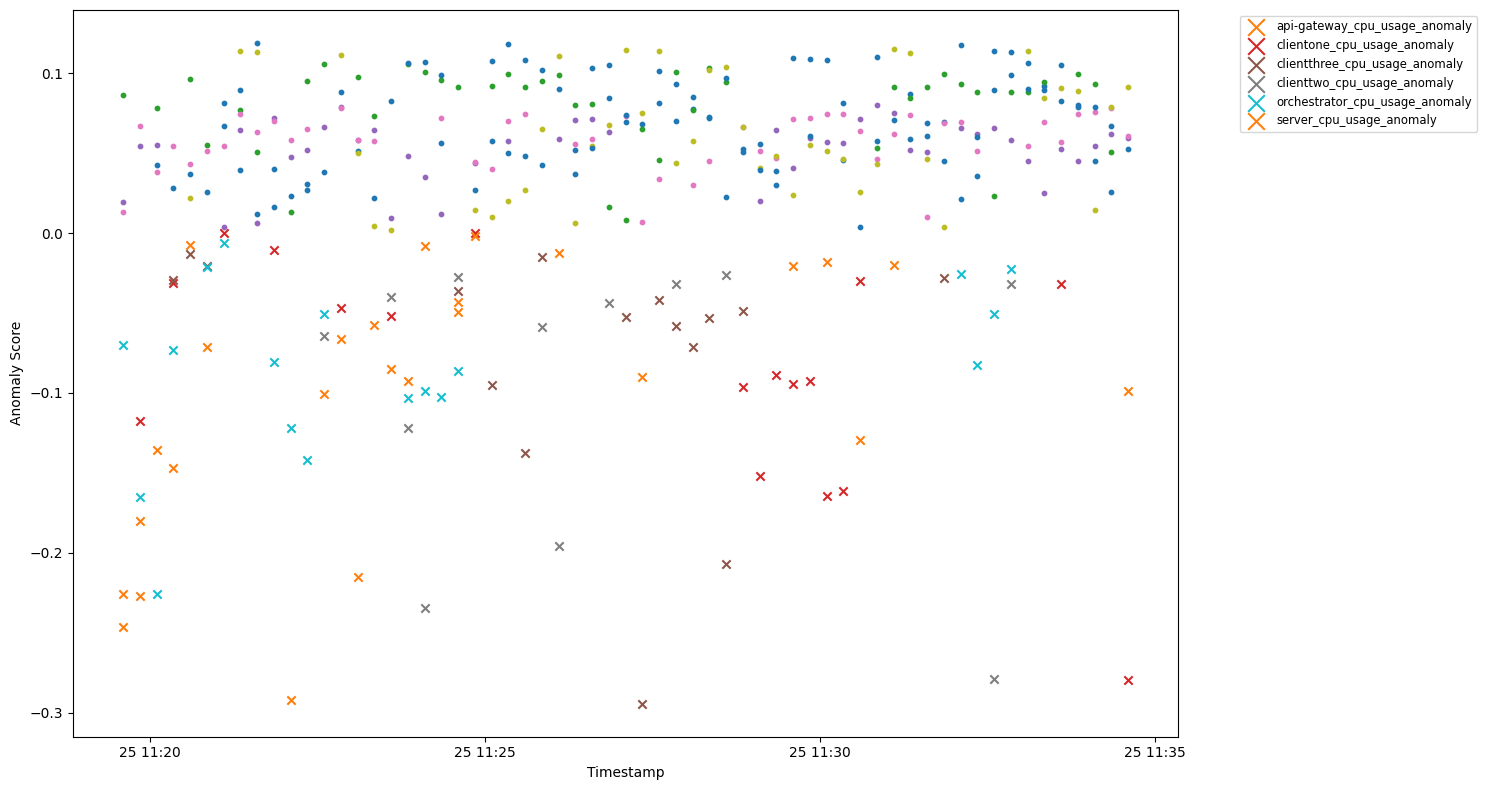

In [33]:
import matplotlib.pyplot as plt
import time

# Visualization of the results
data = pd.read_csv("output/da_data_metrics.csv", index_col="timestamp", parse_dates=True)

plt.figure(figsize=(15, 8))

for column_name in data.columns:
    if column_name.endswith("_anomaly") and "_cpu_usage_" in column_name:
        anomaly_score_column = f"{column_name}_score"
        
        # Plot normal instances
        normal = data[data[column_name] == 1]
        plt.scatter(normal.index, normal[anomaly_score_column], s=10)
        
        # Plot anomalies
        anomalies = data[data[column_name] == -1]
        plt.scatter(anomalies.index, anomalies[anomaly_score_column], marker='x', label=column_name)

plt.xlabel("Timestamp")
plt.ylabel("Anomaly Score")

# Place legend outside the plot to save space
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2, fontsize='small')
plt.tight_layout()

plt.show()

In [59]:
# main_node.execute('$HOME/miniconda/envs/py-venv/bin/pip install "numpy<2.0.0"')